In [1]:
import pandas as pd
import numpy as numpy

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV



In [2]:
df = pd.read_csv('../../data/processed/bank_data_preprocessed_v2.csv')


In [3]:
nominal_cols = ['job', 'marital']
df_processed = pd.get_dummies(df, columns=nominal_cols, drop_first=True)

categorical_cols = ['default', 'housing', 'loan']
for col in categorical_cols:
    df_processed[col] = df_processed[col].map({'yes': 1, 'no': 0})

df_processed.drop(columns=['month'], inplace=True)

In [4]:
X = df_processed.drop(['deposit', 'deposit_bin'], axis=1)
y = df_processed['deposit']

print(f"X shape : {X.shape}")
print(f"y shape : {y.shape}")
print(f"Target distribution:\n{y.value_counts()}")

X shape : (11162, 51)
y shape : (11162,)
Target distribution:
deposit
0    5873
1    5289
Name: count, dtype: int64


In [5]:
# Scale only continuous numerical columns (not binary/OHE flags)
scale_cols = ['age', 'balance_log1p', 'pdays_contacted', 'pdays_contacted', 'campaign_capped', 'previous_log1p']

scaler = StandardScaler()
X_scaled = X.copy()
X_scaled[scale_cols] = scaler.fit_transform(X[scale_cols])

print("Columns standardized (mean≈0, std≈1):")
print(X_scaled[scale_cols].describe().round(3).loc[['mean','std']])

Columns standardized (mean≈0, std≈1):
      age  balance_log1p  pdays_contacted  pdays_contacted  campaign_capped  \
mean  0.0           -0.0              0.0              0.0              0.0   
std   1.0            1.0              1.0              1.0              1.0   

      previous_log1p  
mean            -0.0  
std              1.0  


In [6]:
X_scaled['pdays_contacted'] = X_scaled['pdays_contacted'].fillna(999)

In [7]:
# uswanie Post-treatment variables
X_scaled = X_scaled.drop(['duration'], axis=1)

In [8]:
# ── 6.1  Train / Test Split ──────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.20,       # 80% train | 20% test
    random_state=42,
    stratify=y            # preserve class balance
)

print("Split Summary:")
print(f"  Train  → X: {X_train.shape}  |  y: {y_train.shape}")
print(f"  Test   → X: {X_test.shape}   |  y: {y_test.shape}")
print()
print("Class distribution after stratified split:")
print(f"  Train  yes={y_train.sum()} ({y_train.mean()*100:.1f}%)  "
      f"no={len(y_train)-y_train.sum()} ({(1-y_train.mean())*100:.1f}%)")
print(f"  Test   yes={y_test.sum()} ({y_test.mean()*100:.1f}%)  "
      f"no={len(y_test)-y_test.sum()} ({(1-y_test.mean())*100:.1f}%)")

Split Summary:
  Train  → X: (8929, 50)  |  y: (8929,)
  Test   → X: (2233, 50)   |  y: (2233,)

Class distribution after stratified split:
  Train  yes=4231 (47.4%)  no=4698 (52.6%)
  Test   yes=1058 (47.4%)  no=1175 (52.6%)


In [9]:
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, confusion_matrix, roc_curve, ConfusionMatrixDisplay
from sklearn.model_selection import cross_val_score

In [10]:
from sklearn.svm import SVC

svm = SVC(kernel='rbf', probability=True)
svm.fit(X_train, y_train)

SVC(probability=True)

In [11]:
y_pred = svm.predict(X_test)
y_proba = svm.predict_proba(X_test)[:, 1]

In [12]:

y_pred_svm  = svm.predict(X_test)
y_prob_svm  = svm.predict_proba(X_test)[:, 1]

acc_svm     = accuracy_score(y_test, y_pred_svm)
auc_svm     = roc_auc_score(y_test, y_prob_svm)
cv_scores_svm = cross_val_score(svm, X_scaled, y, cv=5, scoring='accuracy')

print("=" * 50)
print("   Support Vector Machine — Optimised Performance")
print("=" * 50)
print(f"  Test Accuracy     : {acc_svm:.4f}  ({acc_svm*100:.2f}%)")
print(f"  ROC-AUC Score     : {auc_svm:.4f}")
print(f"  5-Fold CV Mean    : {cv_scores_svm.mean():.4f}  ± {cv_scores_svm.std():.4f}")

   Support Vector Machine — Optimised Performance
  Test Accuracy     : 0.6135  (61.35%)
  ROC-AUC Score     : 0.7258
  5-Fold CV Mean    : 0.6133  ± 0.1062


In [13]:
# ── 8.4  Classification Report ───────────────────────────────────────────────
print("Classification Report — Support Vector Machine")
print("─" * 55)
print(classification_report(y_test, y_pred_svm, target_names=['No (0)', 'Yes (1)']))

Classification Report — Support Vector Machine
───────────────────────────────────────────────────────
              precision    recall  f1-score   support

      No (0)       0.59      0.85      0.70      1175
     Yes (1)       0.68      0.35      0.46      1058

    accuracy                           0.61      2233
   macro avg       0.63      0.60      0.58      2233
weighted avg       0.63      0.61      0.59      2233



In [14]:
import matplotlib.pyplot as plt

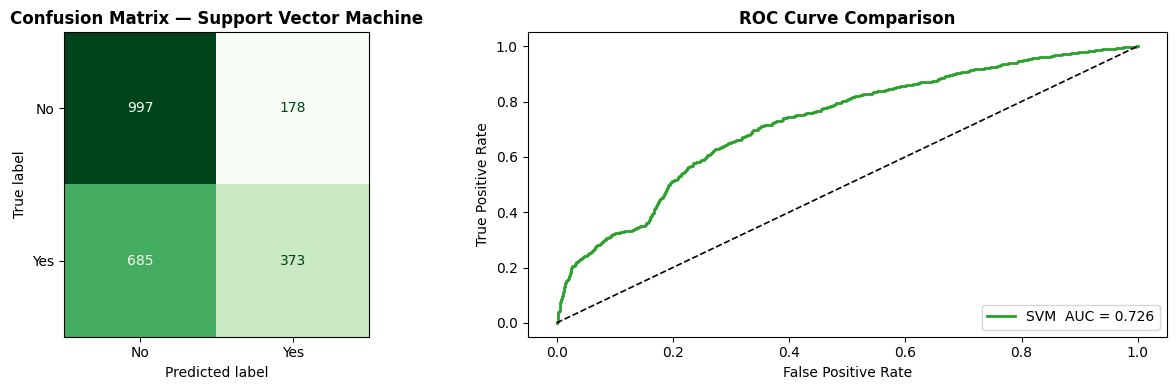

In [15]:
# ── 8.5  Confusion Matrix & ROC Curve ────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Confusion Matrix
cm_svm = confusion_matrix(y_test, y_pred_svm)
disp = ConfusionMatrixDisplay(cm_svm, display_labels=['No', 'Yes'])
disp.plot(ax=axes[0], colorbar=False, cmap='Greens')
axes[0].set_title('Confusion Matrix — Support Vector Machine', fontweight='bold')

# ROC Curve
fpr_svm, tpr_svm, _ = roc_curve(y_test, y_prob_svm)
axes[1].plot(fpr_svm, tpr_svm, color='#2ca02c', lw=2, label=f'SVM  AUC = {auc_svm:.3f}')
axes[1].plot([0,1],[0,1],'k--', lw=1.2)
axes[1].set_xlabel('False Positive Rate'); axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve Comparison', fontweight='bold')
axes[1].legend(loc='lower right')

plt.tight_layout()
plt.show()

### Feature importance

In [16]:
from sklearn.inspection import permutation_importance

result = permutation_importance(
    svm, X_test, y_test,
    n_repeats=10,
    random_state=42
)

importance = pd.Series(result.importances_mean, index=X_test.columns)\
    .sort_values(ascending=False)

print(importance.head(10))

pdays_contacted             0.09897
age                         0.00000
default                     0.00000
housing                     0.00000
pdays                       0.00000
loan                        0.00000
was_previously_contacted    0.00000
has_debt                    0.00000
net_balance_indicator       0.00000
financial_stress            0.00000
dtype: float64


In [19]:
print(X_train.describe().T[['mean', 'std']])

                                mean         std
age                        -0.010511    0.996914
default                     0.014671    0.120240
housing                     0.473625    0.499332
loan                        0.129466    0.335734
pdays                      51.794490  109.077260
was_previously_contacted    0.256132    0.436520
pdays_contacted           743.125064  436.082554
has_debt                    0.529063    0.499183
net_balance_indicator       0.868854    0.337579
financial_stress            0.176616    0.381364
previous_log1p             -0.000428    0.995582
balance_log1p              -0.011715    0.987280
campaign_capped            -0.006645    0.993631
poutcome_is_unknown         0.743980    0.436457
contact_is_unknown          0.210102    0.407404
is_peak_month               0.061261    0.239822


In [20]:
print(svm.score(X_train, y_train))
print(svm.score(X_test, y_test))

0.613170567812745
0.6135244066278549


In [35]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

svm_rbf = Pipeline([
    ("scaler", StandardScaler()),
    ("svc", SVC(
        kernel='rbf',
        C=10,
        gamma=0.1,
        probability=True
    ))
])

svm_rbf.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('svc', SVC(C=10, gamma=0.1, probability=True))])

In [36]:

y_pred_svm  = svm_rbf.predict(X_test)
y_prob_svm  = svm_rbf.predict_proba(X_test)[:, 1]

acc_svm     = accuracy_score(y_test, y_pred_svm)
auc_svm     = roc_auc_score(y_test, y_prob_svm)
cv_scores_svm = cross_val_score(svm_rbf, X_scaled, y, cv=5, scoring='accuracy')

print("=" * 50)
print("   Support Vector Machine — Optimised Performance")
print("=" * 50)
print(f"  Test Accuracy     : {acc_svm:.4f}  ({acc_svm*100:.2f}%)")
print(f"  ROC-AUC Score     : {auc_svm:.4f}")
print(f"  5-Fold CV Mean    : {cv_scores_svm.mean():.4f}  ± {cv_scores_svm.std():.4f}")

   Support Vector Machine — Optimised Performance
  Test Accuracy     : 0.6655  (66.55%)
  ROC-AUC Score     : 0.6953
  5-Fold CV Mean    : 0.6235  ± 0.0908


In [29]:
from sklearn.inspection import permutation_importance

result = permutation_importance(
    svm_rbf, X_test, y_test,
    n_repeats=10,
    random_state=42
)

print(pd.Series(result.importances_mean, index=X_test.columns)
      .sort_values(ascending=False).head(10))

contact_is_unknown    0.016480
marital_married       0.014689
month_oct             0.010614
contact_cellular      0.009942
month_apr             0.007747
job_blue-collar       0.007479
campaign_capped       0.006538
poutcome_success      0.006225
month_jan             0.006135
month_jun             0.006090
dtype: float64


In [37]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'svc__C': [0.1, 1, 10],
    'svc__gamma': ['scale', 0.1, 0.01]
}

grid = GridSearchCV(svm_rbf, param_grid, cv=3)
grid.fit(X_train, y_train)

svm_best = grid.best_estimator_

In [56]:
print(svm_best)

Pipeline(steps=[('scaler', StandardScaler()),
                ('svc', SVC(C=1, gamma=0.01, probability=True))])


In [38]:

y_pred_svm  = svm_best.predict(X_test)
y_prob_svm  = svm_best.predict_proba(X_test)[:, 1]

acc_svm     = accuracy_score(y_test, y_pred_svm)
auc_svm     = roc_auc_score(y_test, y_prob_svm)
cv_scores_svm = cross_val_score(svm_best, X_scaled, y, cv=5, scoring='accuracy')

print("=" * 50)
print("   Support Vector Machine — Optimised Performance")
print("=" * 50)
print(f"  Test Accuracy     : {acc_svm:.4f}  ({acc_svm*100:.2f}%)")
print(f"  ROC-AUC Score     : {auc_svm:.4f}")
print(f"  5-Fold CV Mean    : {cv_scores_svm.mean():.4f}  ± {cv_scores_svm.std():.4f}")

   Support Vector Machine — Optimised Performance
  Test Accuracy     : 0.7143  (71.43%)
  ROC-AUC Score     : 0.7615
  5-Fold CV Mean    : 0.6898  ± 0.1361


In [ ]:
from sklearn.inspection import permutation_importance

result = permutation_importance(
    svm_best, X_test, y_test,
    n_repeats=10,
    random_state=42
)

print(pd.Series(result.importances_mean, index=X_test.columns)
      .sort_values(ascending=False).head(10))

poutcome_success      0.017734
month_oct             0.016749
month_jun             0.011644
contact_is_unknown    0.008330
month_apr             0.006762
month_aug             0.005150
housing               0.005060
month_mar             0.004299
job_retired           0.003717
has_debt              0.003493
dtype: float64


In [39]:
from sklearn.svm import LinearSVC

svm_linear = Pipeline([
    ("scaler", StandardScaler()),
    ("svc", LinearSVC(C=1))
])

svm_linear.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()), ('svc', LinearSVC(C=1))])

In [41]:
y_pred_svm  = svm_linear.predict(X_test)
y_score_svm = svm_linear.decision_function(X_test)

acc_svm = accuracy_score(y_test, y_pred_svm)
auc_svm = roc_auc_score(y_test, y_score_svm)

cv_scores_svm = cross_val_score(svm_linear, X_scaled, y, cv=5, scoring='accuracy')

print("=" * 50)
print("   Support Vector Machine — Optimised Performance")
print("=" * 50)
print(f"  Test Accuracy     : {acc_svm:.4f}  ({acc_svm*100:.2f}%)")
print(f"  ROC-AUC Score     : {auc_svm:.4f}")
print(f"  5-Fold CV Mean    : {cv_scores_svm.mean():.4f}  ± {cv_scores_svm.std():.4f}")

   Support Vector Machine — Optimised Performance
  Test Accuracy     : 0.6937  (69.37%)
  ROC-AUC Score     : 0.7586
  5-Fold CV Mean    : 0.6547  ± 0.1379


In [ ]:
from sklearn.inspection import permutation_importance

result = permutation_importance(
    svm_linear, X_test, y_test,
    n_repeats=10,
    random_state=42
)

print(pd.Series(result.importances_mean, index=X_test.columns)
      .sort_values(ascending=False).head(10))

contact_is_unknown    0.011554
poutcome_success      0.010703
month_oct             0.008688
has_debt              0.006449
job_retired           0.005687
month_nov             0.005598
month_aug             0.004433
contact_cellular      0.004030
month_jan             0.003359
month_jun             0.003045
dtype: float64


dalejd zialamy na `svm_best` 0.71%

### SHAP

In [44]:

import shap

def predict_proba_fn(X):
    return svm_best.predict_proba(X)

X_train_sample = X_train.sample(100, random_state=42)
X_test_sample  = X_test.sample(100, random_state=42)

explainer = shap.KernelExplainer(
    predict_proba_fn,
    X_train_sample
)

c:\Users\user\Desktop\uep.masterthesis\.venv\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [45]:
shap_values = explainer.shap_values(X_test_sample)

  0%|          | 0/100 [00:00<?, ?it/s]

c:\Users\user\Desktop\uep.masterthesis\.venv\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\user\Desktop\uep.masterthesis\.venv\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\user\Desktop\uep.masterthesis\.venv\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\user\Desktop\uep.masterthesis\.venv\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
c:\Users\user\Desktop\uep.masterthesis\.venv\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, b

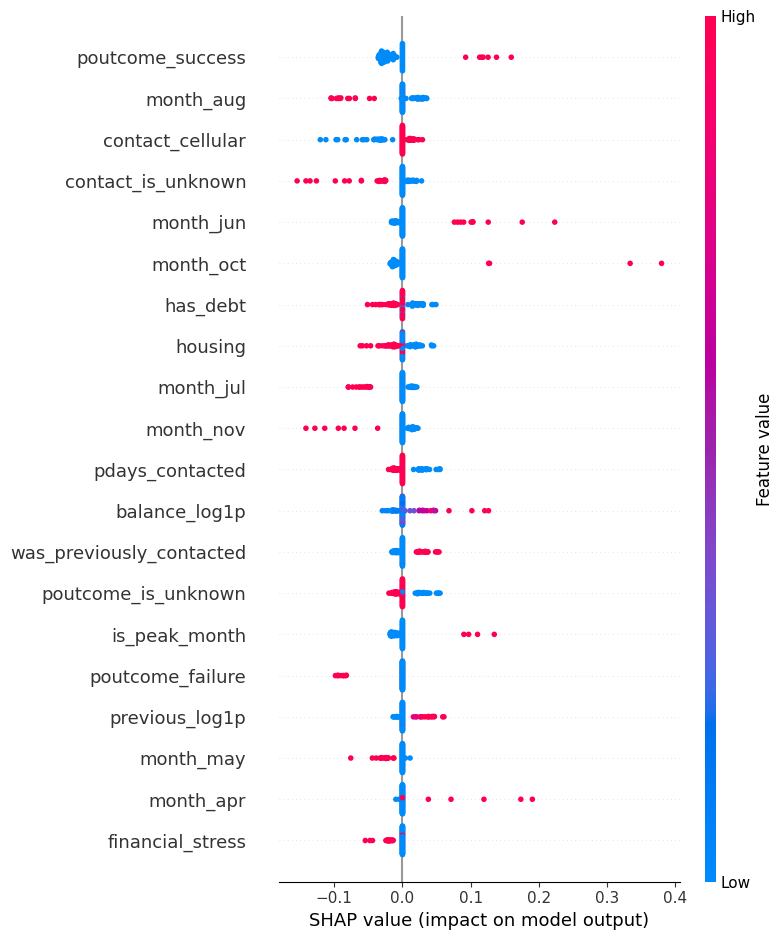

In [52]:
shap.summary_plot(shap_values[:, :, 1], X_test_sample)

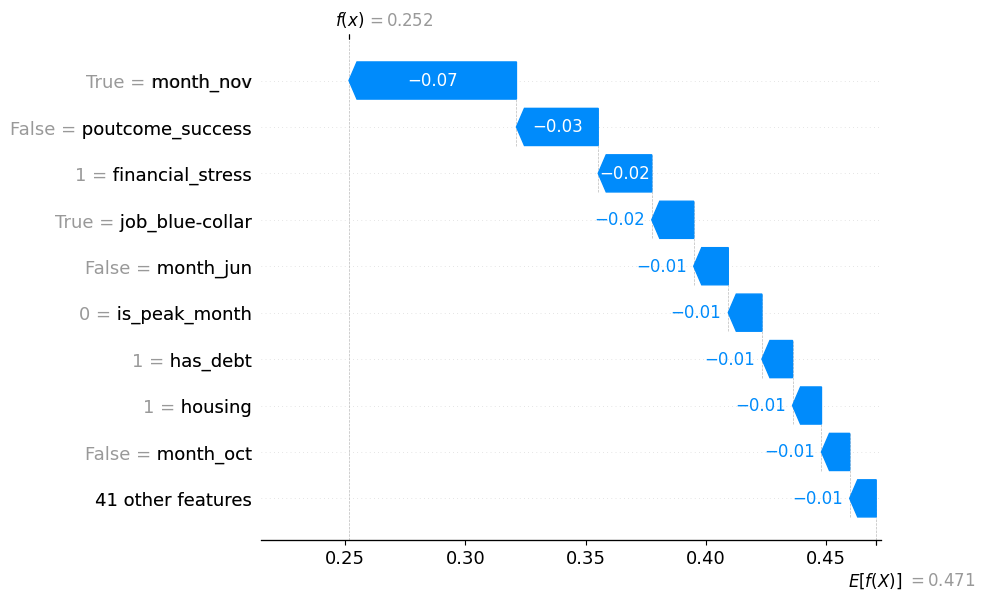

In [55]:
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[0, :, 1],
        base_values=explainer.expected_value[1],
        data=X_test_sample.iloc[0],
        feature_names=X_test_sample.columns
    )
)

**Analiza SHAP**

> 🔴 SVM SHAP = mniej stabilny niż GBM → interpretujemy ostrożniej

| Zmienna                      | SHAP siła        | Rola w DAG                         | Interpretacja przyczynowa             | Nadaje się na T? |
| ---------------------------- | ---------------- | ---------------------------------- | ------------------------------------- | ---------------- |
| **poutcome_success**         | 🔥 bardzo wysoka | confounder Z (historyczny efekt T) | proxy wcześniejszego sukcesu kampanii | ❌                |
| **month_aug / jun / oct**    | 🔥 wysoka        | confounder sezonowy Z              | sezonowość kampanii / timing          | ⚠️               |
| **contact_cellular**         | średnia          | T1 (treatment)                     | kanał kontaktu                        | ✅                |
| **contact_is_unknown**       | średnia          | confounder Z                       | jakość danych / brak kontaktu         | ❌                |
| **has_debt**                 | średnia          | confounder Z                       | ryzyko finansowe                      | ❌                |
| **housing**                  | średnia          | confounder Z                       | zobowiązania finansowe                | ❌                |
| **balance_log1p**            | średnia          | confounder Z                       | status finansowy                      | ❌                |
| **pdays_contacted**          | średnia          | confounder / mediator ⚠️           | historia kontaktu                     | ❌ / ⚠️           |
| **was_previously_contacted** | średnia          | T3 / confounder historyczny        | wcześniejszy kontakt                  | ⚠️ (time issue)  |
| **poutcome_is_unknown**      | niska/średnia    | confounder Z                       | brak informacji historycznej          | ❌                |
| **is_peak_month**            | niska/średnia    | confounder sezonowy                | intensywność kampanii                 | ⚠️               |
| **previous_log1p**           | niska            | confounder historyczny             | liczba wcześniejszych kontaktów       | ❌                |
| **financial_stress**         | niska            | confounder Z                       | stres finansowy                       | ❌                |


### ⚠️ 2. Sezonowość jest nienaturalnie silna

```
month_aug, month_jun, month_oct
```

👉 SVM przypisuje im duży wpływ, ale:

* rozrzut SHAP duży → niestabilność
* efekt zależny od innych zmiennych

📌 Wniosek:

> sezonowość działa jako proxy strategii kampanii, nie jako causal driver

---

### ⚖️ 3. Treatment (`contact_cellular`) jest średnio ważny

👉 SHAP:

* efekt dodatni (czerwone → prawo)
* ale rozrzut duży

📌 interpretacja:

> kanał kontaktu ma wpływ, ale tylko w niektórych segmentach

👉 zgodne z:

* Twoim CausalForest (duża heterogeniczność, brak istotności)

---

### 🔴 4. `pdays_contacted` i `was_previously_contacted`

👉 bardzo ważne rozróżnienie:

| zmienna                  | problem                |
| ------------------------ | ---------------------- |
| pdays_contacted          | może być mediator      |
| was_previously_contacted | wcześniejszy treatment |

📌 wniosek:

> model miesza czas — używa informacji post-treatment

---

### ⚠️ 5. Finansowe zmienne są słabsze niż w GBM

* `balance_log1p`
* `has_debt`
* `financial_stress`

👉 mają wpływ, ale:

> są mniej dominujące niż historia kontaktu

---

### 🚨 **KLUCZOWY META-WNIOSEK**

> **SVM uczy się głównie historii interakcji, a nie efektów interwencji**

czyli:

* model = predykcyjny
* nie = przyczynowy

---

# 🔬 **Porównanie z wcześniejszym modelem (GBM / CF)**

| aspekt                        | SVM             | CausalForest           |
| ----------------------------- | --------------- | ---------------------- |
| historia (`poutcome_success`) | 🔥 bardzo silna | kontrolowana jako Z    |
| treatment effect              | rozmyty         | estymowany (ATE/CATE)  |
| sezonowość                    | przeszacowana   | częściowo kontrolowana |
| interpretowalność             | niska           | wysoka (causal)        |

---

### 🧠 **Interpretacja do pracy**

> Analiza SHAP dla modelu SVM wskazuje, że predykcja decyzji o depozycie jest w największym stopniu determinowana przez zmienne historyczne, w szczególności `poutcome_success`, będące proxy wcześniejszych sukcesów kampanii. Istotną rolę odgrywają również zmienne sezonowe (miesiące), jednak ich wpływ charakteryzuje się dużą niestabilnością. Zmienna interwencyjna `contact_cellular` wykazuje umiarkowany wpływ i wysoką heterogeniczność, co jest spójne z wynikami analizy przyczynowej. Wyniki te sugerują, że model SVM opiera się głównie na wzorcach historycznych i korelacjach, a nie na mechanizmach przyczynowych, co ogranicza jego użyteczność w analizie efektów interwencji.

---

## Conterfactual analysis

**📌 Counterfactual inference z użyciem SVC (S-learner)**

Oszacowujemy **wpływ kontaktu przez telefon komórkowy (treatment)** na to, czy klient założy depozyt.

#### 🧠 Formalizacja problemu

Rozważamy zmienne:

* ( T ) — treatment (czy kontakt był przez cellular)
* ( Y ) — outcome (czy klient założył depozyt)
* ( W ) — confounders (demografia, finanse, historia)
* ( X ) — cechy heterogeniczności efektu (HTE)

---

**📐 Model**

Uczymy jeden model (S-learner):

$$
Y = f(X, W, T)
$$

W praktyce (dla klasyfikacji SVC z `probability=True`) model aproksymuje:

$$
P(Y = 1 \mid X, W, T)
$$

czyli prawdopodobieństwo sukcesu warunkowe na cechach i treatment.

---

**⚙️ Interpretacja modelu SVC**

SVC nie jest modelem probabilistycznym z natury, ale dzięki:

* `probability=True`
* kalibracji (Platt scaling)

otrzymujemy przybliżenie:

$$
\hat{f}(X, W, T) \approx P(Y=1 \mid X, W, T)
$$

To pozwala użyć go w kontekście przyczynowym.

---

**🔁 Counterfactual reasoning**

Dla każdej obserwacji symulujemy dwa światy:

**🔹 Świat faktyczny / treatment**

$$
\hat{Y}_1 = \hat{f}(X, W, T=1)
$$

**🔹 Świat kontrfaktyczny**

$$
\hat{Y}_0 = \hat{f}(X, W, T=0)
$$

---

#### 📊 Efekt przyczynowy

** 🔸 Indywidualny efekt (ITE)**

$$
ITE = \hat{Y}_1 - \hat{Y}_0
$$

Interpretacja:
o ile zmienia się prawdopodobieństwo depozytu dla konkretnej osoby, gdy zmienimy treatment.

---

#### 🔸 Średni efekt (ATE)

$$
ATE = \mathbb{E}[ITE]
$$

Interpretacja:
średni wpływ kontaktu przez cellular w całej populacji.

---

#### 🧪 Kod

**1. Łączy cechy:**

$$
(X, W, T)
$$

czyli:

* cechy klienta
* confoundery
* treatment jako feature

---

**2. Uczy model:**

$$
\hat{f}(X, W, T) \rightarrow Y
$$

---

**3. Tworzymy dwa wejścia:**

* ( T = 1 )
* ( T = 0 )

dla tych samych ( X, W )

---

**4. Liczymy:**

* ( p_1 = P(Y=1 \mid T=1, X, W) )
* ( p_0 = P(Y=1 \mid T=0, X, W) )

---

**5. Różnica:**

$$
ITE = p_1 - p_0
$$

---

### ⚠️ Założenia (krytyczne)

Aby interpretacja była przyczynowa, zakładamy:

**1. Brak ukrytych confounderów (ignorability)**

$$
(Y(1), Y(0)) \perp T \mid X, W
$$

---

**2. Overlap (każdy może dostać treatment)**

$$
0 < P(T=1 \mid X, W) < 1
$$

---

#### ❗ Ograniczenia SVC w tym podejściu

* brak jawnej interpretowalności
* probabilistyka = kalibracja, nie model generatywny
* słabsze modelowanie heterogeniczności niż np. lasy przyczynowe
* brak „wbudowanej” struktury causal (to tylko wrapper)

### a) Sprawdzenie `contact_cellular`

In [ ]:
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

# ─────────────────────────────────────────
# DATA
# ─────────────────────────────────────────

T = df_processed['contact_cellular'].astype(int).values
Y = df_processed['deposit'].astype(int).values

# X = heterogeneity features
X = df_processed[['age', 'balance_log1p', 'pdays_contacted']].astype(float)
X = X.fillna(X.median())

# W = confounders
confounders = [
    'age',
    'balance_log1p',
    'financial_stress',
    'has_debt',
    'net_balance_indicator',
    'default',
    'housing',
    'loan',
    'pdays_contacted',
    'was_previously_contacted',
    'education_primary',
    'education_secondary',
    'education_tertiary',
    'education_unknown',
    'marital_married',
    'marital_single',
    'job_blue-collar',
    'job_entrepreneur',
    'job_housemaid',
    'job_management',
    'job_retired',
    'job_self-employed',
    'job_services',
    'job_student',
    'job_technician',
    'job_unemployed',
    'job_unknown',
    'poutcome_failure',
    'poutcome_other',
    'poutcome_success',
    'poutcome_is_unknown',
    'campaign_capped',
]

confounders = [c for c in confounders if c in df_processed.columns]
W = df_processed[confounders].astype(float)
W = W.fillna(W.median())

# ─────────────────────────────────────────
# BUILD FEATURE MATRIX
# ─────────────────────────────────────────

XW = np.hstack([X.values, W.values])
X_full = np.hstack([XW, T.reshape(-1, 1)])

# ─────────────────────────────────────────
# MODEL (SVC S-learner)
# ─────────────────────────────────────────

model = Pipeline([
    ("scaler", StandardScaler()),
    ("svc", SVC(C=1, gamma=0.01, probability=True))
])

model.fit(X_full, Y)

# ─────────────────────────────────────────
# COUNTERFACTUAL PREDICTIONS
# ─────────────────────────────────────────

# T = 1 (treatment)
# P(Y=1 | T=1, X, W)
X_t1 = np.hstack([XW, np.ones((XW.shape[0], 1))])
p1 = model.predict_proba(X_t1)[:, 1]

# T = 0 (control)
# P(Y=1 | T=0, X, W)
X_t0 = np.hstack([XW, np.zeros((XW.shape[0], 1))])
p0 = model.predict_proba(X_t0)[:, 1]

# ─────────────────────────────────────────
# EFFECTS
# ─────────────────────────────────────────

ite = p1 - p0
ate = ite.mean()

print("ATE (average treatment effect):", ate)
print("ITE sample (first 10):", ite[:10])

ATE (average treatment effect): 0.11306969750550037
ITE sample (first 10): [ 0.06155293  0.23603766  0.06501502  0.05599662  0.24249255  0.0228031
 -0.01554036  0.07210492  0.04713277  0.15559044]


### b) Sprawdzenie `campaign_capped`

In [59]:
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

# ─────────────────────────────────────────
# DATA
# ─────────────────────────────────────────

T = df_processed['campaign_capped'].astype(int).values
Y = df_processed['deposit'].astype(int).values

# X = heterogeneity features
X = df_processed[['age', 'balance_log1p', 'pdays_contacted']].astype(float)
X = X.fillna(X.median())

# W = confounders
confounders = [
    'age',
    'balance_log1p',
    'financial_stress',
    'has_debt',
    'net_balance_indicator',
    'default',
    'housing',
    'loan',
    'pdays_contacted',
    'was_previously_contacted',
    'education_primary',
    'education_secondary',
    'education_tertiary',
    'education_unknown',
    'marital_married',
    'marital_single',
    'job_blue-collar',
    'job_entrepreneur',
    'job_housemaid',
    'job_management',
    'job_retired',
    'job_self-employed',
    'job_services',
    'job_student',
    'job_technician',
    'job_unemployed',
    'job_unknown',
    'poutcome_failure',
    'poutcome_other',
    'poutcome_success',
    'poutcome_is_unknown',
    'contact_cellular',
]

confounders = [c for c in confounders if c in df_processed.columns]
W = df_processed[confounders].astype(float)
W = W.fillna(W.median())

# ─────────────────────────────────────────
# BUILD FEATURE MATRIX
# ─────────────────────────────────────────

XW = np.hstack([X.values, W.values])
X_full = np.hstack([XW, T.reshape(-1, 1)])

# ─────────────────────────────────────────
# MODEL (SVC S-learner)
# ─────────────────────────────────────────

model = Pipeline([
    ("scaler", StandardScaler()),
    ("svc", SVC(C=1, gamma=0.01, probability=True))
])

model.fit(X_full, Y)

# ─────────────────────────────────────────
# COUNTERFACTUAL PREDICTIONS
# ─────────────────────────────────────────

# T = 1 (treatment)
X_t1 = np.hstack([XW, np.ones((XW.shape[0], 1))])
p1 = model.predict_proba(X_t1)[:, 1]

# T = 0 (control)
X_t0 = np.hstack([XW, np.zeros((XW.shape[0], 1))])
p0 = model.predict_proba(X_t0)[:, 1]

# ─────────────────────────────────────────
# EFFECTS
# ─────────────────────────────────────────

ite = p1 - p0
ate = ite.mean()

print("ATE (average treatment effect):", ate)
print("ITE sample (first 10):", ite[:10])

ATE (average treatment effect): -0.01603059938775892
ITE sample (first 10): [-0.01019049 -0.03652249 -0.01171236 -0.00916392 -0.0436526  -0.00273882
 -0.00547612 -0.01579946 -0.01063703 -0.00641943]


### c) Sprawdzenie `was_previously_contacted`

In [60]:
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

# ─────────────────────────────────────────
# DATA
# ─────────────────────────────────────────

T = df_processed['was_previously_contacted'].astype(int).values
Y = df_processed['deposit'].astype(int).values

# X = heterogeneity features
X = df_processed[['age', 'balance_log1p', 'pdays_contacted']].astype(float)
X = X.fillna(X.median())

# W = confounders
confounders = [
    'age',
    'balance_log1p',
    'financial_stress',
    'has_debt',
    'net_balance_indicator',
    'default',
    'housing',
    'loan',
    'pdays_contacted',
    'education_primary',
    'education_secondary',
    'education_tertiary',
    'education_unknown',
    'marital_married',
    'marital_single',
    'job_blue-collar',
    'job_entrepreneur',
    'job_housemaid',
    'job_management',
    'job_retired',
    'job_self-employed',
    'job_services',
    'job_student',
    'job_technician',
    'job_unemployed',
    'job_unknown',
    'poutcome_failure',
    'poutcome_other',
    'poutcome_success',
    'poutcome_is_unknown',
    'contact_cellular',
    'campaign_capped',
]

confounders = [c for c in confounders if c in df_processed.columns]
W = df_processed[confounders].astype(float)
W = W.fillna(W.median())

# ─────────────────────────────────────────
# BUILD FEATURE MATRIX
# ─────────────────────────────────────────

XW = np.hstack([X.values, W.values])
X_full = np.hstack([XW, T.reshape(-1, 1)])

# ─────────────────────────────────────────
# MODEL (SVC S-learner)
# ─────────────────────────────────────────

model = Pipeline([
    ("scaler", StandardScaler()),
    ("svc", SVC(C=1, gamma=0.01, probability=True))
])

model.fit(X_full, Y)

# ─────────────────────────────────────────
# COUNTERFACTUAL PREDICTIONS
# ─────────────────────────────────────────

# T = 1 (treatment)
X_t1 = np.hstack([XW, np.ones((XW.shape[0], 1))])
p1 = model.predict_proba(X_t1)[:, 1]

# T = 0 (control)
X_t0 = np.hstack([XW, np.zeros((XW.shape[0], 1))])
p0 = model.predict_proba(X_t0)[:, 1]

# ─────────────────────────────────────────
# EFFECTS
# ─────────────────────────────────────────

ite = p1 - p0
ate = ite.mean()

print("ATE (average treatment effect):", ate)
print("ITE sample (first 10):", ite[:10])

ATE (average treatment effect): 0.06107480297540697
ITE sample (first 10): [0.08501679 0.112823   0.07906881 0.08753451 0.11793408 0.07592087
 0.08684511 0.06036119 0.07848323 0.06028048]


### 📊 Wyniki

#### 1. Przegląd zbadanych Treatmentów

| Treatment                       | ATE    | Istotność | Heterogeniczność (na podstawie ITE) |
| ------------------------------- | ------ | --------- | ----------------------------------- |
| `campaign_capped` (T2)          | -0.016 | brak info | niska                               |
| `was_previously_contacted` (T3) | +0.061 | brak info | niska–umiarkowana                   |

---

#### 2. T2: Intensywność kampanii (`campaign_capped`)

ATE = -0.016 wskazuje na **lekko negatywny efekt** liczby kontaktów na prawdopodobieństwo depozytu.

| Metryka | Wartość          | Interpretacja               |
| ------- | ---------------- | --------------------------- |
| ATE     | -0.016           | bardzo mały efekt negatywny |
| ITE     | ~[-0.04, -0.002] | efekt spójnie ujemny        |

**Wniosek:** efekt jest bliski zeru i niewielki — brak silnego wpływu zmiennej na wynik.

---

#### 3. T3: Historia kontaktu (`was_previously_contacted`)

ATE = +0.061 wskazuje na **pozytywny efekt** wcześniejszego kontaktu.

| Metryka | Wartość       | Interpretacja                |
| ------- | ------------- | ---------------------------- |
| ATE     | +0.061        | umiarkowany efekt pozytywny  |
| ITE     | ~[0.06, 0.11] | efekt dodatni dla obserwacji |

**Wniosek:** zmienna jest związana z wyższym prawdopodobieństwem depozytu.

---

#### 4. Synteza i interpretacja globalna

| Obszar                | Wniosek                            |
| --------------------- | ---------------------------------- |
| Intensywność kampanii | efekt bliski zeru, lekko negatywny |
| Historia kontaktu     | efekt dodatni                      |

---

### 5. Finalna konkluzja

> W analizie uzyskano jeden niewielki efekt negatywny (`campaign_capped`) oraz jeden umiarkowany efekt pozytywny (`was_previously_contacted`). Oba efekty są stabilne kierunkowo na poziomie obserwacji (ITE).
